# Clustering analysis

In [1]:
import joblib
import os
import time

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from anomaly.utils import get_sdss_spec_img
from astroExplain.spectra import clustering
from astroExplain.spectra import astronomy
from sdss.metadata import MetaData

meta = MetaData()

# Custom functions

## Data

In [2]:
def load_xai_arrs(run_ids_dict: dict, load_from: str):

    anomalies_arr = np.load(f"{load_from}/spectra_anomalies.npy", mmap_mode="r")
    specobjids_array = np.load(f"{load_from}/specobjids_anomalies.npy", mmap_mode="r")

    weights_dict = {}

    for n_segments in run_ids_dict.keys():

        run_id = run_ids_dict[n_segments]

        weights_dict[n_segments] = np.load(
            f"{load_from}/explanation_array_{run_id}.npy", mmap_mode="r"
        )
    return anomalies_arr, specobjids_array, weights_dict

In [3]:
def weights_prep(weights, n_segments):
    """
    Function to prepare the weights data for clustering.
    """

    data_dict = {
        "weights": weights.copy(),
        "norm_weights": None,
        "unique_weights": None,
        "norm_unique_weights": None,
    }

    data_dict["norm_weights"] = clustering.normalize_weights_l2_abs(
        data_dict["weights"]
    )

    data_dict["unique_weights"] = clustering.compress_weights_per_segments(
        weights=data_dict["weights"], n_segments=n_segments
    )

    data_dict["norm_unique_weights"] = clustering.normalize_weights_l2_abs(
        data_dict["unique_weights"]
    )

    return data_dict

## Averages in clusters

In [4]:
def plot_averages_clusters(
    spectra_cluster_dict,
    weights_cluster_dict,
    wave,
):

    n_clusters = len(spectra_cluster_dict)

    fig, axs = plt.subplots(
        nrows=n_clusters,
        ncols=2,
        figsize=None,
        sharex=True,
        sharey=False,
        tight_layout=True,
    )

    # set minor ticks on
    for ax in axs.flatten():
        ax.minorticks_on()

    #  weights of centroid

    for label, cluster_weights in weights_cluster_dict.items():

        avg_weights = cluster_weights.mean(axis=0)
        avg_weights /= np.max(avg_weights)

        avg_spectrum = spectra_cluster_dict[label].mean(axis=0)

        axs[label, 0].plot(
            wave,
            avg_spectrum,
            color="black",
        )
        # weights
        axs[label, 1].plot(wave, avg_weights, color="black", label=f"Cluster {label}")

        axs[label, 1].legend(
            [f"Cluster {label}"],
            fontsize=6,
            handlelength=0,
            handletextpad=0,
            loc="upper right",
            frameon=False,
        )
        # set limits
        axs[label, 1].set_ylim(0, 1.1)

    axs[n_clusters - 1, 0].set_xlabel(r"$\lambda$ [nm]")
    axs[n_clusters - 1, 1].set_xlabel(r"$\lambda$ [nm]")

    return fig, axs

## Top ranked explanations

In [5]:
def plot_top_ranked_explanations(
    metadata_df,
    spectra,
    norm_weights,
    wave,
    kmeans_model_dir,
    cluster_id,
    donwload_images=True,
    n_top_ranked=20,
    max_norm_weights=False,
):
    n_anomalies_in_cluster = metadata_df.shape[0]
    print(f"Number of anomalies in cluster {cluster_id}: {n_anomalies_in_cluster}")

    for anomaly_rank in range(0, n_anomalies_in_cluster):
        print(f"Explanation for anomaly rank {anomaly_rank + 1}")
        if anomaly_rank == n_top_ranked:
            break

        anomaly_idx = n_anomalies_in_cluster - 1 - anomaly_rank
        specobjid = metadata_df.index[anomaly_idx]

        if donwload_images is True:
            os.makedirs(f"{kmeans_model_dir}/cluster_{cluster_id}", exist_ok=True)

            # check if the image already exists
            image_path = (
                f"{kmeans_model_dir}/cluster_{cluster_id}/image_{specobjid}.jpeg"
            )

            if not os.path.exists(image_path):

                ra, dec = metadata_df[["ra", "dec"]].loc[specobjid].values
                get_sdss_spec_img(
                    specobjid,
                    ra,
                    dec,
                    save_to=f"{kmeans_model_dir}/cluster_{cluster_id}",
                )

        spec = spectra[anomaly_idx]

        norm_weights_spec = norm_weights[anomaly_idx]
        if max_norm_weights is True:
            norm_weights_spec /= np.max(norm_weights_spec)

        fig, axs = plt.subplots(
            nrows=2,
            ncols=1,
            figsize=None,
            sharex=True,
            sharey=False,
        )
        # set minor ticks on
        for ax in axs.flatten():
            ax.minorticks_on()
        axs[0].plot(wave, spec, color="black")
        # weights
        axs[1].plot(
            wave, norm_weights_spec, color="black", label=f"Cluster {cluster_id}"
        )

        axs[1].set_xlabel(r"$\lambda$ [nm]")
        axs[0].set_ylabel("Normalized flux")
        axs[1].set_ylabel("Explanation weights")
        axs[0].set_title(
            f"Rank: {anomaly_rank + 1:02d} - Cluster: {cluster_id}\n"
            f"Specobjid: {specobjid}"
        )

        axs[1].set_ylim(0, 1)

        image_name = f"image_{specobjid}.jpeg"
        # Load the image
        img = mpimg.imread(f"{kmeans_model_dir}/cluster_{cluster_id}/{image_name}")

        # Create inset in top-right corner of axs[0]
        width_height_image = 1
        axins = inset_axes(
            axs[0],
            width=width_height_image,
            height=width_height_image,
            bbox_to_anchor=(1.01, 1.02),
            bbox_transform=axs[0].transAxes,
            loc="upper right",
        )

        # Show image in the inset
        axins.imshow(img)
        axins.axis("off")  # Hide axis around the image
        explanation_name = f"rank_{anomaly_rank + 1:02d}_explanation_{specobjid}"
        if max_norm_weights is True:
            explanation_name += "_max_norm"

        save_pdf_dir = f"{kmeans_model_dir}/cluster_{cluster_id}"
        save_jpeg_dir = f"{save_pdf_dir}/explanations_sdss_spec_jpeg"
        # create directories if they don't exist
        os.makedirs(save_pdf_dir, exist_ok=True)
        os.makedirs(save_jpeg_dir, exist_ok=True)
        fig.savefig(f"{save_pdf_dir}/{explanation_name}.pdf", bbox_inches="tight")
        fig.savefig(f"{save_jpeg_dir}/{explanation_name}.jpeg", bbox_inches="tight")
        plt.clf()
        plt.close(fig)

# Config

## Directories

In [6]:
phd_dir = "/home/elom/phd"
thesis_dir = f"{phd_dir}/thesis"
data_dir = f"{phd_dir}/code"
spectra_dir = f"{data_dir}/spectra"
scores_dir = f"{data_dir}/scores"
models_dir = f"{data_dir}/models"
latent_dir = f"{data_dir}/latent"
explanations_dir = f"{data_dir}/explanations"
clustering_dir = f"{data_dir}/clustering"

## Constants

In [7]:
score_name = "mse_filter_250"
bin_id = "bin_03"
n_segments = 221
n_clusters = 8

kmeans_model_id = f"kmeans_{n_clusters}_clusters_{n_segments}_segments"
kmeans_model_dir = f"{clustering_dir}/{bin_id}/{score_name}/{kmeans_model_id}"

if not os.path.exists(kmeans_model_dir):
    os.makedirs(kmeans_model_dir)
print(f"Model ID: {kmeans_model_id}")

Model ID: kmeans_8_clusters_221_segments


## Data

In [8]:
wave = np.load(f"{spectra_dir}/wave_spectra_imputed.npy")
wave_nm = wave * 0.1

spectra = np.load(f"{spectra_dir}/spectra_imputed.npy", mmap_mode="r")

final_meta_df = pd.read_csv(
    f"{spectra_dir}/final_spec_n_z_warning_drop.csv.gz",
    index_col="specobjid",
)

meta_with_ratios_df = pd.read_csv(
    f"{spectra_dir}/final_spec_n_z_warning_drop_with_ratios.csv.gz",
    index_col="specobjid",
)
idx_id_spec = np.load(f"{spectra_dir}/ids_imputing.npy", mmap_mode="r")

## Explanations

In [9]:
run_ids_filter_se_dict = {
    "221": "xai_202606230243_uniform_221_samples_5000_scale_0.9",
}

load_from = f"{explanations_dir}/{bin_id}/{score_name}/"

anomalies_arr, specobjids_array, weights_dict = load_xai_arrs(
    run_ids_dict=run_ids_filter_se_dict, load_from=load_from
)

xai_dict = weights_prep(weights=weights_dict[f"{n_segments}"], n_segments=n_segments)

Base size: 17, Residual size: 16
New number of segments: 222


# K-means model
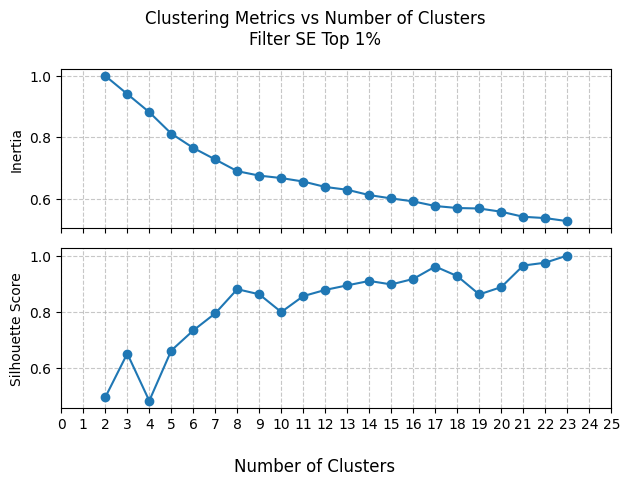

## Train and save

```python
start_time = time.perf_counter()
kmeans_model = KMeans(n_clusters=n_clusters, random_state=0).fit(
    xai_dict["norm_unique_weights"]
)
end_time = time.perf_counter()
print(f"train time: {end_time - start_time:.2f} seconds")

# save the model
joblib.dump(kmeans_model, f"{kmeans_model_dir}/kmeans_model.joblib")
```

```
train time: 0.15 seconds
['/home/elom/phd/code/clustering/bin_03/mse_filter_250/kmeans_8_clusters_221_segments/kmeans_model.joblib']kmeans_model.joblib']
```

## Save metadata

```python
kmeans_model = joblib.load(f"{kmeans_model_dir}/kmeans_model.joblib")

cluster_meta_df = meta_with_ratios_df.loc[specobjids_array].copy()
cluster_meta_df["cluster"] = kmeans_model.labels_

cluster_meta_df.to_csv(f"{kmeans_model_dir}/metadata.csv.gz", compression="gzip")
```

# Clusters metadata

In [ ]:
kmeans_model = joblib.load(f"{kmeans_model_dir}/kmeans_model.joblib")
cluster_labels = kmeans_model.labels_

# get spectra and weights per cluster
spectra_cluster_dict, weights_cluster_dict = clustering.group_spectra_by_cluster(
    cluster_labels=cluster_labels,
    anomalies_array=anomalies_arr,
    weights=xai_dict["norm_weights"],
    print_n_clusters=True,
)

xai_dict["spectra_cluster_dict"] = spectra_cluster_dict
xai_dict["weights_cluster_dict"] = weights_cluster_dict

_, unique_weights_cluster_dict = clustering.group_spectra_by_cluster(
    cluster_labels=cluster_labels,
    anomalies_array=anomalies_arr,
    weights=xai_dict["norm_unique_weights"],
    print_n_clusters=False,
)

xai_dict["unique_weights_cluster_dict"] = unique_weights_cluster_dict
centroids = kmeans_model.cluster_centers_
xai_dict["centroids"] = centroids

# 0;244
# 1;303
# 2;74
# 3;91
# 4;469
# 5;134
# 6;225
# 7;279

0;244
1;303
2;74
3;91
4;469
5;134
6;225
7;279


In [13]:
cluster_meta_df = pd.read_csv(
    f"{kmeans_model_dir}/metadata.csv.gz", index_col="specobjid"
)
cluster_meta_df.shape

(1819, 52)

# Avg Spec & Explanations

In [14]:
# for clustering library compatibility
# n_segments -= 1

for label, centroid in enumerate(xai_dict["centroids"]):

    fig, axs = plt.subplots(
        nrows=2,
        ncols=1,
        figsize=None,
        sharex=True,
        sharey=False,
    )

    # set minor ticks on
    for ax in axs.flatten():
        ax.minorticks_on()

    centroid = clustering.expand_weights_per_segments(
        centroid.reshape(1, -1),
        wave_nm.size,
        n_segments,
    )

    centroid = centroid.reshape(-1)
    avg_spectrum = spectra_cluster_dict[label].mean(axis=0)

    axs[0].plot(wave_nm, avg_spectrum, color="black", label="Average spectrum")
    axs[0].legend()
    # weights
    axs[1].plot(wave_nm, centroid, color="black", label="Average explanation")
    axs[1].legend()
    # set limits
    axs[1].set_ylim(0, 1.1)
    axs[1].set_xlabel(r"$\lambda$ [nm]")

    fig.suptitle(
        f"Cluster {label}",
        fontsize=12,
    )

    plot_name = f"avg_spec_centroid_{label}"

    save_to = f"{kmeans_model_dir}/avg_spec_centroids"
    os.makedirs(save_to, exist_ok=True)

    fig.savefig(f"{save_to}/{plot_name}.pdf", bbox_inches="tight")
    fig.savefig(f"{save_to}/{plot_name}.jpeg", bbox_inches="tight")
    plt.clf()
    plt.close(fig)

## Top ranked anomalies per cluster

In [22]:
cluster_id = 0

mask = cluster_meta_df["cluster"] == cluster_id
metadata_df = cluster_meta_df.loc[mask].copy()

spectra = anomalies_arr[mask]
norm_weights = xai_dict["norm_weights"][mask]

plot_top_ranked_explanations(
    cluster_id=cluster_id,
    metadata_df=metadata_df,
    spectra=spectra,
    norm_weights=norm_weights,
    wave=wave_nm,
    kmeans_model_dir=kmeans_model_dir,
    donwload_images=True,
    n_top_ranked=20,
    max_norm_weights=False,
)

Number of anomalies in cluster 0: 244
Explanation for anomaly rank 1
Explanation for anomaly rank 2
Explanation for anomaly rank 3
Explanation for anomaly rank 4
Explanation for anomaly rank 5
Explanation for anomaly rank 6
Explanation for anomaly rank 7
Explanation for anomaly rank 8
Explanation for anomaly rank 9
Explanation for anomaly rank 10
Explanation for anomaly rank 11
Explanation for anomaly rank 12
Explanation for anomaly rank 13
Explanation for anomaly rank 14
Explanation for anomaly rank 15
Explanation for anomaly rank 16
Explanation for anomaly rank 17
Explanation for anomaly rank 18
Explanation for anomaly rank 19
Explanation for anomaly rank 20
Explanation for anomaly rank 21


# Line ratios

In [23]:
lines_cols = [
    "h_alpha_flux",
    "h_beta_flux",
    "nii_6548_flux",
    "nii_6584_flux",
    "sii_6717_flux",
    "sii_6731_flux",
    "oii_3726_flux",
    "oii_3729_flux",
    "oiii_4959_flux",
    "oiii_5007_flux",
    "oiii_flux",
]
cluster_meta_df[lines_cols].describe()

,h_alpha_flux,h_beta_flux,nii_6548_flux,nii_6584_flux,sii_6717_flux,sii_6731_flux,oii_3726_flux,oii_3729_flux,oiii_4959_flux,oiii_5007_flux,oiii_flux
count,1.779000e+03,1.772000e+03,1.754000e+03,1.754000e+03,1.707000e+03,1.711000e+03,1.339000e+03,1.358000e+03,1.704000e+03,1.768000e+03,1.771000e+03
mean,1.760467e+07,4.989428e+06,1.844849e+06,5.564490e+06,8.704647e+06,1.760793e+08,1.460533e+07,6.166428e+06,2.656667e+06,3.627812e+06,3.656661e+06
std,5.782993e+08,1.608409e+08,6.623184e+07,1.997705e+08,2.474328e+08,7.188085e+09,3.163725e+08,1.787694e+08,6.982418e+07,1.112902e+08,1.121025e+08
min,2.159138e-01,5.402843e-03,3.730642e-02,1.125248e-01,1.745283e-02,5.457369e-02,6.603864e-02,6.811889e-02,2.608672e-02,4.893990e-02,2.465294e-02
25%,2.565707e+02,7.075481e+01,2.392849e+01,7.217383e+01,6.290468e+01,4.323960e+01,4.549995e+01,4.529957e+01,1.996945e+01,4.591517e+01,4.682148e+01
50%,7.717072e+02,2.132489e+02,5.696440e+01,1.718177e+02,1.339990e+02,9.863401e+01,1.822480e+02,1.878684e+02,1.140318e+02,3.193071e+02,3.213557e+02
75%,1.582117e+03,4.364138e+02,1.221093e+02,3.683098e+02,2.274099e+02,1.685509e+02,4.580174e+02,4.507408e+02,3.514105e+02,1.001983e+03,1.014668e+03
max,2.292654e+10,6.261624e+09,2.727109e+09,8.225589e+09,9.422665e+09,2.973184e+11,9.037692e+09,6.529991e+09,2.468186e+09,4.029195e+09,4.046059e+09


In [24]:
n_nans = cluster_meta_df[lines_cols].isna().sum()
n_negatives = (cluster_meta_df[lines_cols] < 0).sum()
n_zeros = (cluster_meta_df[lines_cols] == 0).sum()
temp_df = pd.DataFrame(
    {"n_nans": n_nans, "n_negatives": n_negatives, "n_zeros": n_zeros}
)
temp_df.index.name = "line_flux_column"
temp_df = temp_df.reset_index()
temp_df

,line_flux_column,n_nans,n_negatives,n_zeros
0,h_alpha_flux,40,0,0
1,h_beta_flux,47,0,0
2,nii_6548_flux,65,0,0
3,nii_6584_flux,65,0,0
4,sii_6717_flux,112,0,0
5,sii_6731_flux,108,0,0
6,oii_3726_flux,480,0,0
7,oii_3729_flux,461,0,0
8,oiii_4959_flux,115,0,0
9,oiii_5007_flux,51,0,0


In [25]:
# Compute deciles (10th to 90th percentiles) for each column
deciles = np.arange(0.01, 1.01, 0.01)
decile_df = cluster_meta_df[lines_cols].quantile(q=deciles).T

decile_df.columns = [f"{int(q * 100)}th" for q in deciles]
decile_df

,1th,2th,3th,4th,5th,6th,6th,8th,9th,10th,...,91th,92th,93th,94th,95th,96th,97th,98th,99th,100th
h_alpha_flux,3.513266,5.905969,8.140174,10.676639,14.350330,18.174829,23.545310,27.441655,33.785823,39.352814,...,2839.314100,3035.307840,3221.826500,3392.591600,3641.98440,4040.805680,4508.758820,5324.433800,6.309090e+03,2.292654e+10
h_beta_flux,0.810949,2.277306,2.931588,3.999180,6.198709,7.731425,9.116316,10.592370,12.600511,15.057317,...,797.259670,860.128136,897.307129,975.919526,1057.12730,1140.524000,1281.316570,1435.941460,1.676762e+03,6.261624e+09
nii_6548_flux,0.509845,1.078331,1.660767,2.582181,3.836492,4.975902,5.958830,6.959913,7.667360,8.545722,...,222.481139,233.578888,255.841200,272.842212,316.66416,360.337988,403.282958,476.433178,6.866601e+02,2.727109e+09
nii_6584_flux,1.537811,3.252495,5.009254,7.788452,11.571744,15.008473,17.973208,20.992710,23.126523,25.775869,...,671.054466,704.527836,771.676177,822.955156,955.13220,1086.863000,1216.394460,1437.032360,2.071125e+03,8.225589e+09
sii_6717_flux,1.564226,2.322364,3.582317,5.442791,7.816944,9.256939,11.225437,12.788270,15.287371,18.140124,...,350.370580,366.207776,379.624682,398.898492,424.62621,465.663696,524.391818,583.886260,7.030981e+02,9.422665e+09
sii_6731_flux,1.183201,2.396094,3.699149,4.580869,5.726767,7.285017,8.199962,9.377604,10.419004,12.035150,...,272.794950,282.806740,295.900460,309.239900,338.80735,368.997260,399.210580,477.018040,5.665525e+02,2.973184e+11
oii_3726_flux,0.959286,2.127023,3.224647,4.387434,5.337616,6.706018,8.977916,9.285191,10.440342,11.155694,...,883.280774,947.182344,1010.788120,1094.648320,1264.02750,1555.991520,2384.775980,46695.190400,1.633065e+06,9.037692e+09
oii_3729_flux,0.613714,1.379655,2.070460,3.626907,4.754077,7.057983,9.425058,10.918732,12.335353,13.748500,...,829.618696,864.888324,925.568291,982.673792,1117.22265,1210.349920,1391.196810,2146.965480,2.390021e+06,6.529991e+09
oiii_4959_flux,0.341027,0.720565,1.305199,1.671687,2.329868,2.824663,3.119683,3.636708,4.116400,4.923749,...,834.523519,895.923972,955.917959,1066.335820,1187.15340,1311.426360,1542.570150,1714.293980,2.109939e+03,2.468186e+09
oiii_5007_flux,1.515168,2.439940,3.411862,4.620056,5.626666,6.568327,7.656896,8.628446,9.856083,10.879268,...,2468.306850,2631.158320,2860.949370,3152.926520,3510.63035,3945.065440,4676.126410,5224.428180,6.253495e+03,4.029195e+09


In [26]:
# replace 0 with NaN
cluster_meta_df[lines_cols] = cluster_meta_df[lines_cols].replace(0, np.nan)
# replace negative fluxes numeric values with NaN
cluster_meta_df[lines_cols] = cluster_meta_df[lines_cols].where(
    cluster_meta_df[lines_cols] >= 0, np.nan
)
n_zeros = (cluster_meta_df[lines_cols] == 0).sum()
n_negatives = (cluster_meta_df[lines_cols] < 0).sum()
temp_df = pd.DataFrame({"n_negatives": n_negatives, "n_zeros": n_zeros})
temp_df.index.name = "line_flux_column"
temp_df = temp_df.reset_index()
temp_df

,line_flux_column,n_negatives,n_zeros
0,h_alpha_flux,0,0
1,h_beta_flux,0,0
2,nii_6548_flux,0,0
3,nii_6584_flux,0,0
4,sii_6717_flux,0,0
5,sii_6731_flux,0,0
6,oii_3726_flux,0,0
7,oii_3729_flux,0,0
8,oiii_4959_flux,0,0
9,oiii_5007_flux,0,0


# Median line ratios

In [27]:
df, ratio_cols = astronomy.compute_emission_line_ratios(cluster_meta_df)
range_n_clusters = range(0, n_clusters)

median_cluster_ratios_df = pd.DataFrame(
    index=range_n_clusters,
    columns=ratio_cols,
)
for cluster_id in range_n_clusters:

    mask = df["cluster"] == cluster_id

    median_cluster_ratios_df.loc[cluster_id, "balmer_decrement"] = np.nanmedian(
        df.loc[mask, "balmer_decrement"]
    )
    median_cluster_ratios_df.loc[cluster_id, "nii_to_halpha"] = np.nanmedian(
        df.loc[mask, "nii_to_halpha"]
    )
    median_cluster_ratios_df.loc[cluster_id, "oiii_to_hbeta"] = np.nanmedian(
        df.loc[mask, "oiii_to_hbeta"]
    )
    median_cluster_ratios_df.loc[cluster_id, "oiii_to_oii"] = np.nanmedian(
        df.loc[mask, "oiii_to_oii"]
    )
    median_cluster_ratios_df.loc[cluster_id, "o3n2_index"] = np.nanmedian(
        df.loc[mask, "o3n2_index"]
    )
    median_cluster_ratios_df.loc[cluster_id, "sii_to_halpha"] = np.nanmedian(
        df.loc[mask, "sii_to_halpha"]
    )
    median_cluster_ratios_df.loc[cluster_id, "sii_density_ratio"] = np.nanmedian(
        df.loc[mask, "sii_density_ratio"]
    )

median_cluster_ratios_df

,balmer_decrement,nii_to_halpha,oiii_to_hbeta,oiii_to_oii,o3n2_index,sii_to_halpha,sii_density_ratio
0,3.366546,0.102536,3.55069,3.026943,1.475392,0.196747,1.357734
1,3.933751,0.441987,0.888974,0.867055,0.210042,0.3176,1.351016
2,3.961697,0.383219,1.81418,1.657243,0.767128,0.307064,1.27444
3,4.183817,0.595834,3.017471,3.75042,0.755647,0.316503,1.2392
4,3.485227,0.334094,0.809867,0.776618,0.300736,0.301903,1.402635
5,3.224886,0.122142,1.869163,1.146079,1.186104,0.272993,1.417711
6,3.937583,0.326824,1.5389,1.746383,0.680749,0.241094,1.304658
7,3.361997,0.157702,1.749284,1.266385,1.027837,0.263558,1.39519


In [28]:
percentiles = np.arange(0.45, 0.55, 0.01)
ratios_percentiles_df = df[ratio_cols].quantile(q=percentiles).T
ratios_percentiles_df.columns = [f"{int(q * 100)}th" for q in percentiles]
ratios_percentiles_df

,45th,46th,47th,48th,49th,50th,51th,52th,53th,54th,55th
balmer_decrement,3.487975,3.506051,3.528186,3.551442,3.570776,3.595096,3.613802,3.625180,3.645039,3.666140,3.685424
nii_to_halpha,0.245660,0.249400,0.253896,0.261296,0.267933,0.275427,0.283360,0.289788,0.295509,0.303366,0.310543
oiii_to_hbeta,1.411438,1.452950,1.495171,1.536621,1.588201,1.634219,1.679685,1.709570,1.764755,1.794322,1.823865
oiii_to_oii,1.146317,1.171467,1.184126,1.224396,1.252324,1.279179,1.305374,1.347160,1.384855,1.412142,1.464562
o3n2_index,0.674363,0.685889,0.713143,0.734039,0.752545,0.766814,0.789062,0.802273,0.821757,0.849814,0.863104
sii_to_halpha,0.268890,0.270697,0.272935,0.275420,0.277378,0.279689,0.281651,0.284302,0.286828,0.288601,0.290834
sii_density_ratio,1.354354,1.357421,1.359972,1.362596,1.366476,1.369167,1.372304,1.374426,1.376302,1.380027,1.381937


## Cluster 0 ratios percentiles

In [29]:
cluster_mask = df["cluster"] == 0
percentiles = np.arange(0.40, 0.65, 0.05)
ratios_percentiles_df = df.loc[cluster_mask, ratio_cols].quantile(q=percentiles).T
ratios_percentiles_df.columns = [f"{int(q * 100)}th" for q in percentiles]
ratios_percentiles_df

,40th,45th,50th,55th,60th
balmer_decrement,3.284539,3.334867,3.366546,3.395428,3.442001
nii_to_halpha,0.082427,0.090922,0.102536,0.107639,0.118207
oiii_to_hbeta,3.195464,3.383740,3.550690,3.760499,3.983057
oiii_to_oii,2.687016,2.810337,3.026943,3.166025,3.459319
o3n2_index,1.355560,1.437212,1.475392,1.533081,1.586190
sii_to_halpha,0.178802,0.186533,0.196747,0.208603,0.219252
sii_density_ratio,1.332870,1.347003,1.357734,1.367180,1.378299


## Cluster 1 ratios percentiles

In [30]:
cluster_mask = df["cluster"] == 1
percentiles = np.arange(0.40, 0.65, 0.05)
ratios_percentiles_df = df.loc[cluster_mask, ratio_cols].quantile(q=percentiles).T
ratios_percentiles_df.columns = [f"{int(q * 100)}th" for q in percentiles]
ratios_percentiles_df

,40th,45th,50th,55th,60th
balmer_decrement,3.786079,3.859147,3.933751,4.018951,4.147518
nii_to_halpha,0.375103,0.390865,0.441987,0.485889,0.549819
oiii_to_hbeta,0.676929,0.775396,0.888974,0.954809,1.121821
oiii_to_oii,0.716642,0.773789,0.867055,0.977488,1.096630
o3n2_index,0.089572,0.143043,0.210042,0.269042,0.327657
sii_to_halpha,0.299225,0.307637,0.317600,0.333635,0.355508
sii_density_ratio,1.308368,1.331748,1.351016,1.374057,1.397587


## Cluster 2 percentiles

In [31]:
cluster_mask = df["cluster"] == 2
percentiles = np.arange(0.40, 0.65, 0.05)
ratios_percentiles_df = df.loc[cluster_mask, ratio_cols].quantile(q=percentiles).T
ratios_percentiles_df.columns = [f"{int(q * 100)}th" for q in percentiles]
ratios_percentiles_df

,40th,45th,50th,55th,60th
balmer_decrement,3.843256,3.908941,3.961697,4.042356,4.072526
nii_to_halpha,0.325371,0.354218,0.383219,0.424525,0.482641
oiii_to_hbeta,1.411077,1.677045,1.814180,2.242163,2.821465
oiii_to_oii,1.363453,1.479580,1.657243,2.646942,3.500399
o3n2_index,0.695153,0.741714,0.767128,0.779135,0.803922
sii_to_halpha,0.287477,0.290124,0.307064,0.319598,0.330886
sii_density_ratio,1.257897,1.265130,1.274440,1.284302,1.301235


## Cluster 3 ratios percentiles

In [32]:
cluster_mask = df["cluster"] == 3
percentiles = np.arange(0.40, 0.65, 0.05)
ratios_percentiles_df = df.loc[cluster_mask, ratio_cols].quantile(q=percentiles).T
ratios_percentiles_df.columns = [f"{int(q * 100)}th" for q in percentiles]
ratios_percentiles_df

,40th,45th,50th,55th,60th
balmer_decrement,4.021028,4.158310,4.183817,4.243436,4.298820
nii_to_halpha,0.495351,0.574715,0.595834,0.614115,0.650944
oiii_to_hbeta,2.496892,2.806473,3.017471,3.523192,4.013932
oiii_to_oii,2.342406,3.239160,3.750420,4.311743,4.962806
o3n2_index,0.716645,0.735069,0.755647,0.797953,0.810164
sii_to_halpha,0.305698,0.309458,0.316503,0.340878,0.356029
sii_density_ratio,1.180819,1.214497,1.239200,1.257085,1.276070


## Cluster 4 ratios percentiles

In [33]:
cluster_mask = df["cluster"] == 4
percentiles = np.arange(0.40, 0.65, 0.05)
ratios_percentiles_df = df.loc[cluster_mask, ratio_cols].quantile(q=percentiles).T
ratios_percentiles_df.columns = [f"{int(q * 100)}th" for q in percentiles]
ratios_percentiles_df

,40th,45th,50th,55th,60th
balmer_decrement,3.315018,3.388212,3.485227,3.622835,3.727001
nii_to_halpha,0.284704,0.309839,0.334094,0.357522,0.382747
oiii_to_hbeta,0.628758,0.717014,0.809867,0.921182,1.115963
oiii_to_oii,0.634167,0.689241,0.776618,0.881130,0.974344
o3n2_index,0.129897,0.184749,0.300736,0.421529,0.511845
sii_to_halpha,0.286172,0.294413,0.301903,0.314619,0.329422
sii_density_ratio,1.373774,1.389399,1.402635,1.416746,1.433247


## Cluster 5 percentiles

In [34]:
cluster_mask = df["cluster"] == 5
percentiles = np.arange(0.40, 0.65, 0.05)
ratios_percentiles_df = df.loc[cluster_mask, ratio_cols].quantile(q=percentiles).T
ratios_percentiles_df.columns = [f"{int(q * 100)}th" for q in percentiles]
ratios_percentiles_df

,40th,45th,50th,55th,60th
balmer_decrement,3.160943,3.197967,3.224886,3.293603,3.374660
nii_to_halpha,0.105671,0.110796,0.122142,0.143354,0.161924
oiii_to_hbeta,1.529281,1.717094,1.869163,2.076632,2.194480
oiii_to_oii,0.959614,1.052847,1.146079,1.594940,2.043801
o3n2_index,0.976464,1.108262,1.186104,1.280904,1.310974
sii_to_halpha,0.251338,0.266527,0.272993,0.286145,0.297182
sii_density_ratio,1.407739,1.414333,1.417711,1.422780,1.425678


## Cluster 6 percentiles

In [35]:
cluster_mask = df["cluster"] == 6
percentiles = np.arange(0.40, 0.65, 0.05)
ratios_percentiles_df = df.loc[cluster_mask, ratio_cols].quantile(q=percentiles).T
ratios_percentiles_df.columns = [f"{int(q * 100)}th" for q in percentiles]
ratios_percentiles_df

,40th,45th,50th,55th,60th
balmer_decrement,3.805944,3.876897,3.937583,4.026836,4.131584
nii_to_halpha,0.252973,0.294263,0.326824,0.350270,0.370534
oiii_to_hbeta,1.175615,1.351534,1.538900,1.733896,1.856093
oiii_to_oii,1.554797,1.632396,1.746383,1.867098,2.112906
o3n2_index,0.502109,0.570648,0.680749,0.735482,0.800411
sii_to_halpha,0.218977,0.230244,0.241094,0.255172,0.262488
sii_density_ratio,1.263894,1.288953,1.304658,1.325272,1.345870


## Cluster 7 percentiles

In [38]:
cluster_mask = df["cluster"] == 7
percentiles = np.arange(0.40, 0.65, 0.05)
ratios_percentiles_df = df.loc[cluster_mask, ratio_cols].quantile(q=percentiles).T
ratios_percentiles_df.columns = [f"{int(q * 100)}th" for q in percentiles]
ratios_percentiles_df

,40th,45th,50th,55th,60th
balmer_decrement,3.256261,3.318103,3.361997,3.404708,3.457814
nii_to_halpha,0.140753,0.148102,0.157702,0.166603,0.183135
oiii_to_hbeta,1.538097,1.653228,1.749284,1.824447,1.964054
oiii_to_oii,1.106319,1.147586,1.266385,1.339769,1.402905
o3n2_index,0.919256,0.982515,1.027837,1.091664,1.143086
sii_to_halpha,0.247979,0.255999,0.263558,0.270501,0.280623
sii_density_ratio,1.373629,1.383757,1.395190,1.402205,1.410160


# Redshift Analysis

In [39]:
z_dict = {"cluster": [], "z_min": [], "z_max": [], "z_mean": [], "z_median": []}

for cluster_id in range(0, n_clusters):

    mask = cluster_meta_df["cluster"] == cluster_id
    z = cluster_meta_df["z"].loc[mask].values

    z_dict["cluster"].append(cluster_id)
    z_dict["z_min"].append(np.min(z))
    z_dict["z_max"].append(np.max(z))
    z_dict["z_mean"].append(np.mean(z))
    z_dict["z_median"].append(np.median(z))
z_df = pd.DataFrame(z_dict)
z_df

,cluster,z_min,z_max,z_mean,z_median
0,0,0.010132,0.214736,0.047291,0.029884
1,1,0.016985,0.229779,0.092656,0.085483
2,2,0.074165,0.111827,0.108014,0.108261
3,3,0.041688,0.243756,0.116143,0.118335
4,4,0.011196,0.294866,0.088362,0.072381
5,5,0.010093,0.151883,0.020662,0.013714
6,6,0.010354,0.282081,0.083417,0.071541
7,7,0.011001,0.237981,0.052257,0.033541


In [40]:
low_wave, upper_wave = 5_565, 5_590
z_df["lower_wave_min"] = low_wave / (1 + z_df["z_min"])
z_df["upper_wave_min"] = upper_wave / (1 + z_df["z_min"])
z_df["lower_wave_max"] = low_wave / (1 + z_df["z_max"])
z_df["upper_wave_max"] = upper_wave / (1 + z_df["z_max"])
z_df["lower_wave_mean"] = low_wave / (1 + z_df["z_mean"])
z_df["upper_wave_mean"] = upper_wave / (1 + z_df["z_mean"])
z_df["lower_wave_median"] = low_wave / (1 + z_df["z_median"])
z_df["upper_wave_median"] = upper_wave / (1 + z_df["z_median"])
z_df

,cluster,z_min,z_max,z_mean,z_median,lower_wave_min,upper_wave_min,lower_wave_max,upper_wave_max,lower_wave_mean,upper_wave_mean,lower_wave_median,upper_wave_median
0,0,0.010132,0.214736,0.047291,0.029884,5509.182778,5533.932027,4581.243853,4601.824463,5313.707124,5337.578225,5403.519048,5427.793617
1,1,0.016985,0.229779,0.092656,0.085483,5472.056949,5496.639415,4525.203309,4545.532165,5093.094273,5115.974301,5126.748185,5149.779399
2,2,0.074165,0.111827,0.108014,0.108261,5180.766919,5204.040805,5005.272850,5027.758353,5022.500654,5045.063550,5021.381475,5043.939344
3,3,0.041688,0.243756,0.116143,0.118335,5342.293000,5366.292520,4474.352073,4494.452487,4985.921030,5008.319597,4976.149356,4998.504026
4,4,0.011196,0.294866,0.088362,0.072381,5503.382043,5528.105233,4297.740346,4317.047356,5113.188530,5136.158829,5189.387126,5212.699737
5,5,0.010093,0.151883,0.020662,0.013714,5509.396417,5534.146625,4831.220676,4852.924273,5452.344537,5476.838448,5489.711435,5514.373211
6,6,0.010354,0.282081,0.083417,0.071541,5507.972000,5532.715810,4340.597692,4360.097233,5136.524335,5159.599467,5193.456730,5216.787623
7,7,0.011001,0.237981,0.052257,0.033541,5504.446737,5529.174710,4495.221374,4515.415540,5288.630213,5312.388659,5384.403864,5408.592560


In [ ]:
q